# Semi-supervised GMM

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.fftpack import fft
from scipy.interpolate import make_splrep
from scipy.special import logsumexp

# from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.utils import to_time_series_dataset
from tsfresh.feature_extraction import feature_calculators as feat_calc

import pyLasaDataset as lasa
# from hmmlearn import hmm
# from tqdm.auto import tqdm

Using LASA DataSet from /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet


### Hyperparameters

In [2]:
# seed = 0
seed = 42
seq_length = 1000
rng = np.random.default_rng(seed)
window_size = 10
window_step = 5

In [3]:
# max_iter = 300
# tol = 1e-6
beta = 0.5

## Data

In [4]:
# series1 = rng.normal(loc=0, scale=1, size=(seq_length, 2))
# series2 = rng.normal(loc=5, scale=1, size=(seq_length, 2))
# series3 = rng.normal(loc=-3, scale=1, size=(seq_length, 2))
# data = np.stack([series1, series2, series3])
# data.shape

In [5]:
means = np.array(
    [
        [1, 3],
        [3, 1],
        [2.5, 2.5],
    ]
)
covs = np.eye(2) * 0.08
data = np.ones((means.shape[0], seq_length, 2)) * np.nan
for idx in range(means.shape[0]):
    data[idx, :, :] = rng.multivariate_normal(
        mean=means[idx, :], cov=covs, size=(seq_length)
    )
data.shape

(3, 1000, 2)

In [6]:
K_components = data.shape[0]

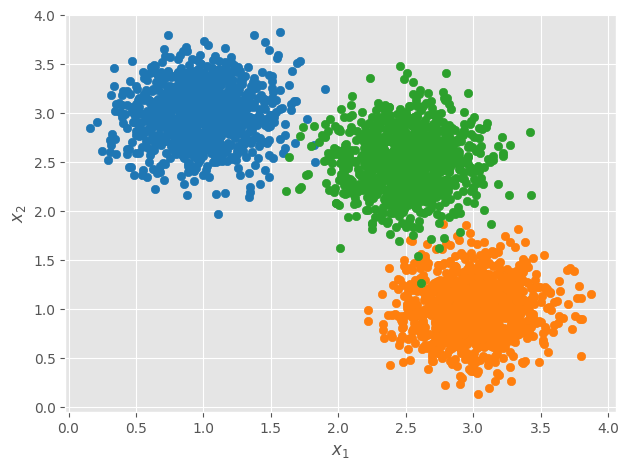

In [7]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(data.shape[0]):
        ax.scatter(data[idx, :, 0], data[idx, :, 1], color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

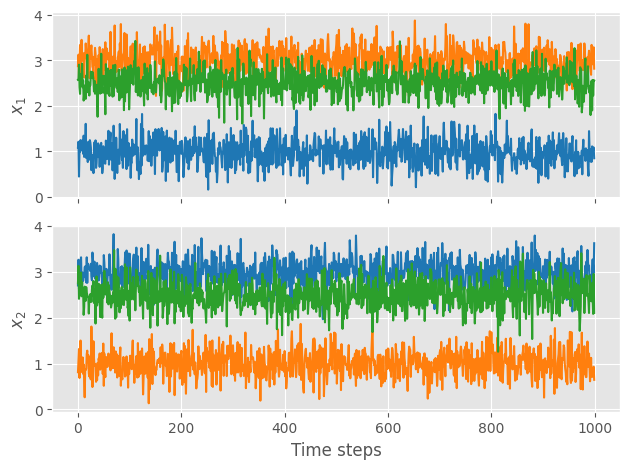

In [8]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(data.shape[-1], 1, sharex=True)
    for idx in range(data.shape[-1]):
        for jdx in range(data.shape[0]):
            ax[idx].plot(data[jdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

## Preprocessing & feature engineering

In [9]:
# dataset = to_time_series_dataset(data)
# dataset.shape

In [10]:
# scaler = TimeSeriesScalerMeanVariance()
# data_scaled = np.squeeze(scaler.fit_transform(data))
# data_scaled.shape

In [11]:
def sliding_window(series, window_size, step):
    windows = []
    for i in range(0, len(series) - window_size + 1, step):
        windows.append(series[i : i + window_size])
    return np.array(windows)

In [12]:
windows = []
for idx in range(data.shape[0]):
    data_sc_i = data[idx, :, :]
    windows.append(
        sliding_window(series=data_sc_i, window_size=window_size, step=window_step)
    )
windows = np.array(windows)
windows.shape

(3, 199, 10, 2)

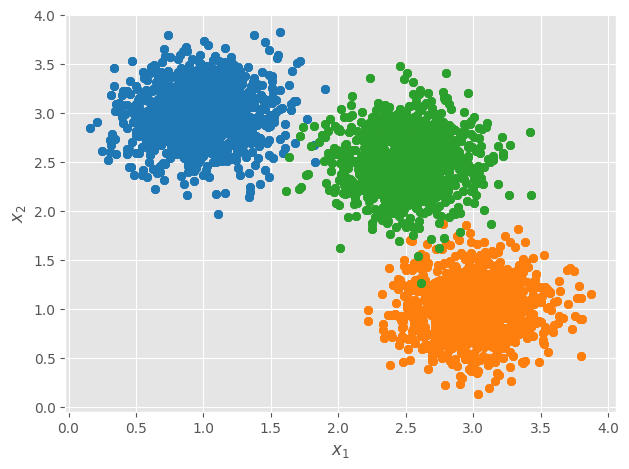

In [13]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        for jdx in range(windows.shape[1]):
            ax.scatter(
                windows[idx, jdx, :, 0], windows[idx, jdx, :, 1], color=cmap[idx]
            )
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

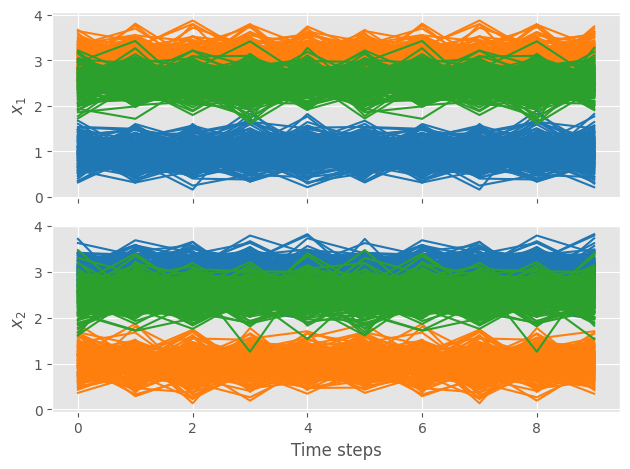

In [14]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            for kdx in range(windows.shape[1]):
                ax[idx].plot(windows[jdx, kdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [15]:
def loop_on_col(arr, funct, *args, **kwargs):
    res = []
    for col in range(arr.shape[1]):
        res.append(funct(arr[:, col], *args, **kwargs))
    return res

In [16]:
def extract_features(windows, lag=5, bins=10):
    features = []
    for win in windows:
        feats = [
            # np.mean(win),
            # np.std(win),
            # np.min(win),
            # np.max(win),
            # np.median(win),
            # np.percentile(win, 25),
            # np.percentile(win, 75),
            # *np.abs(fft(win)).flatten()[:5]
            *loop_on_col(arr=win, funct=feat_calc.abs_energy),
            feat_calc.absolute_sum_of_changes(win),
            feat_calc.autocorrelation(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.benford_correlation),
            # feat_calc.binned_entropy(x=win, max_bins=bins),
            feat_calc.c3(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.cid_ce, normalize=True),
            # *loop_on_col(arr=win, funct=feat_calc.fourier_entropy, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.kurtosis),
            *loop_on_col(arr=win, funct=feat_calc.lempel_ziv_complexity, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_above_mean),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_below_mean),
            feat_calc.mean_abs_change(win),
            *feat_calc.mean_change(win),
            *feat_calc.mean_second_derivative_central(win),
            *loop_on_col(
                arr=win,
                funct=feat_calc.percentage_of_reoccurring_datapoints_to_all_datapoints,
            ),
            *loop_on_col(
                arr=win, funct=feat_calc.percentage_of_reoccurring_values_to_all_values
            ),
            feat_calc.ratio_value_number_to_time_series_length(win),
            feat_calc.root_mean_square(win),
            feat_calc.sample_entropy(win),
            *loop_on_col(arr=win, funct=feat_calc.skewness),
            feat_calc.time_reversal_asymmetry_statistic(x=win, lag=lag),
            feat_calc.variation_coefficient(win),
            # ToDo: add curvature feature
        ]
        features.append(feats)
    return np.array(features)

In [17]:
features = []
for idx in range(windows.shape[0]):
    window_i = windows[idx, :, :]
    features.append(extract_features(window_i))
features = np.array(features)
features.shape

(3, 199, 33)

In [18]:
classes_gt = np.array(
    [np.ones(features.shape[1]) * idx for idx in range(features.shape[0])]
).flatten()
classes_gt

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [19]:
feat_mat = features.reshape(features.shape[0] * features.shape[1], features.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,11.571485,86.341783,18.752872,1.896223,0.833662,0.310942,13.308673,4.772010,4.906791,6.100929,...,0.0,0.0,0.0,1.0,2.212615,0.810930,-2.258800,0.562416,0.0,0.485177
1,12.709689,89.755904,18.707712,1.915477,0.807168,0.298659,14.080955,5.856260,3.712232,-0.400289,...,0.0,0.0,0.0,1.0,2.263466,0.599621,-0.188444,0.249853,0.0,0.462235
2,12.265597,89.192342,19.000588,1.867807,0.579097,0.298659,13.917389,4.974479,5.302902,0.647201,...,0.0,0.0,0.0,1.0,2.252309,0.949081,0.928191,0.500174,0.0,0.479429
3,12.378357,91.999116,19.420928,1.920861,0.695527,0.182761,14.602032,4.560505,5.329494,0.592182,...,0.0,0.0,0.0,1.0,2.284485,0.622530,0.688056,-0.209876,0.0,0.482678
4,9.853358,96.168471,21.260276,1.942633,0.637557,0.136829,15.368119,3.800681,4.320406,-0.893521,...,0.0,0.0,0.0,1.0,2.302410,0.530628,-0.322555,0.334846,0.0,0.530708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,57.325784,63.977332,5.843352,0.054216,0.641886,0.555807,14.761605,3.617696,3.175069,-1.922034,...,0.0,0.0,0.0,1.0,2.462754,0.485508,0.016838,0.221448,0.0,0.173588
593,57.987973,69.507652,4.350880,-0.120396,0.555807,0.295657,15.928067,3.191300,4.837460,-0.321979,...,0.0,0.0,0.0,1.0,2.524833,0.117783,0.598811,-0.956856,0.0,0.131381
594,67.508181,62.238007,2.316396,-0.053877,0.305010,0.295657,16.431788,4.599328,3.630807,-1.145693,...,0.0,0.0,0.0,1.0,2.547020,0.117783,0.689216,0.204262,0.0,0.103646
595,59.244543,62.907607,2.809483,-0.700124,0.394728,0.295657,14.924374,4.439041,4.380154,3.159197,...,0.0,0.0,0.0,1.0,2.471357,0.117783,-0.961352,0.213899,0.0,0.098440


In [20]:
# scaler = StandardScaler()
# feat_mat = scaler.fit_transform(feat_mat)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

### Supervised data

In [21]:
supervised_sample_size = 10
idx_superv = np.random.choice(
    np.arange(classes_gt.shape[0]), size=supervised_sample_size, replace=False
)
Y = np.zeros((len(idx_superv), K_components))
for idxi, idx_val in enumerate(idx_superv):
    Y[idxi, int(classes_gt[int(idx_val)])] = 1
# Y = classes_gt[idx_superv]
X = feat_mat.iloc[idx_superv, :]
X.shape, Y

((10, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.]]))

## GMM clustering

In [22]:
def e_step(U, pi_mixing_prior, mu, Sigma, seed=None, allow_singular=False):
    """
    Compute the expectation step (equation 4).

    U: unlabeled training data
    """
    N = U.shape[0]
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    gamma_resp = np.exp(log_probs - log_norm)
    return gamma_resp

In [23]:
def m_step(U, X, Y, gamma_resp, beta=0.5, reg_coef=1e-3):
    """
    Compute the maximization step.
    """
    assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
    assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
    M, D = X.shape
    N, _ = U.shape
    K = gamma_resp.shape[1]

    pi_mixing_prior_new = np.zeros(K) * np.nan
    mu_new = np.zeros((K, D)) * np.nan
    Sigma_new = np.zeros((K, D, D)) * np.nan

    for k in range(K):
        common_term = (1 - beta) * gamma_resp.sum(axis=0)[k] + beta * Y.sum(axis=0)[k]

        # Update mixing coefficients (equation 5)
        pi_mixing_prior_new[k] = common_term / ((1 - beta) * N + beta * M)

        # Update means (equation 6)
        gamma_resp_u = 0
        gamma_resp_x = 0
        for n in range(N):
            gamma_resp_u += gamma_resp[n, k] * U[n, :]
        for m in range(M):
            gamma_resp_x += gamma_resp[m, k] * X[m, :]
        mu_new[k, :] = ((1 - beta) * gamma_resp_u + beta * gamma_resp_x) / common_term

        # Update covariances (equation 7)
        gamma_resp_u_mu = 0
        gamma_resp_x_mu = 0
        for n in range(N):
            gamma_resp_u_mu += (
                gamma_resp[n, k] * (U[n, :] - mu_new[k]) * (U[n, :] - mu_new[k]).T
            )
        for m in range(M):
            gamma_resp_x_mu += (
                gamma_resp[n, k] * (X[m, :] - mu_new[k]) * (X[m, :] - mu_new[k]).T
            )
        # Sigma_new[k] = ((1 - beta) * gamma_resp_u_mu) / common_term + (
        #     beta * gamma_resp_x_mu
        # ) / common_term
        var = ((1 - beta) * gamma_resp_u_mu) / common_term + (
            beta * gamma_resp_x_mu
        ) / common_term

        # # regularization for numerical stability (optional, small jitter)
        # Sigma_new[j] += reg_coef*np.eye(D)

        # # Constrain the covariance matrices to be diagonal
        # var = (gamma_resp[:, k][:, None] * diff**2).sum(axis=0) / Nk[k]
        Sigma_new[k] = np.diag(var + reg_coef)
    return pi_mixing_prior_new, mu_new, Sigma_new

In [24]:
def log_likelihood(U, X, Y, pi_mixing_prior, mu, Sigma, beta=0.5, allow_singular=False):
    """
    Compute the log-likelihood (equation 9).
    """
    assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
    assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
    M, D = X.shape
    N, _ = U.shape
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))
    log_lik_unsuperv = np.zeros((N, K))
    log_lik_superv = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    log_lik_unsuperv = (1 - beta) * log_norm.sum(axis=0)

    for m in range(M):
        for k in range(K):
            # ToDo: may need to convert the multiplication by `Y[m, k]` to a sum of log
            log_lik_superv[m, k] = Y[m, k] * np.log(
                pi_mixing_prior[k]
            ) + multivariate_normal.logpdf(
                x=X[m, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_lik_superv = beta * log_lik_superv.sum()

    return log_lik_unsuperv + log_lik_superv

In [25]:
def run_EM(
    K_components,
    U,
    X,
    Y,
    beta=0.5,
    reg_coef=1e-3,
    max_iter=300,
    tol=1e-6,
    seed=None,
    allow_singular=False,
):
    """
    Expectation-Maximization algorithm.

    Implemented from [1].

    [1] Yan, H.-C., Zhou, J.-H., & Pang, C. K. (2017).
    Gaussian Mixture Model Using Semisupervised Learning for Probabilistic Fault Diagnosis Under New Data Categories.
    IEEE Transactions on Instrumentation and Measurement, 66(4), 723–733.
    https://doi.org/10.1109/TIM.2017.2654552

    """

    # Initialization
    N, D = X.shape
    pi_mixing_prior = np.ones(K_components) / K_components
    # pi_mixing_prior = np.random.uniform(size=K_components)
    # pi_mixing_prior = pi_mixing_prior/pi_mixing_prior.sum()
    # mu = np.random.rand(K_components, D) * 10.0
    kmeans_init = KMeans(n_clusters=K_components, random_state=seed).fit(X=X)
    mu = np.array(kmeans_init.cluster_centers_)
    # Sigma = np.array([np.eye(D) * rng.uniform(low=0, high=0.01, size=D) for _ in range(K_components)])
    Sigma = np.array([np.eye(D) for _ in range(K_components)])

    lls = []
    for it in range(max_iter):
        # E-step
        gamma_resp = e_step(
            U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
        )

        # M-step
        pi_mixing_prior, mu, Sigma = m_step(
            U=U, X=X, Y=Y, gamma_resp=gamma_resp, reg_coef=reg_coef
        )

        # Log-likelihood
        ll = log_likelihood(
            U=U,
            X=X,
            Y=Y,
            pi_mixing_prior=pi_mixing_prior,
            mu=mu,
            Sigma=Sigma,
            allow_singular=allow_singular,
        )
        lls.append(ll)

        # Logging during training
        if it % 10 == 0:
            # plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')
            print(f"{it}/{max_iter} max iterations -- Log-likelihood: {ll[0]}")

        # Convergence check
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            print(f"\n--- Converged at iteration {it + 1} ---\n")
            break

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots()
        ax.plot(lls, marker=".", c="k")
        ax.set_title("EM training")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        # ax.set_grid(True, alpha=0.3)
        plt.show()

    labels_pred = np.argmax(gamma_resp, axis=1)
    return mu, Sigma, gamma_resp, labels_pred, pi_mixing_prior

In [26]:
def predict(X, pi_mixing_prior, mu, Sigma, seed=None):
    gamma_resp = e_step(
        X=X, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
    )
    labels_pred = np.argmax(gamma_resp, axis=1)
    return gamma_resp, labels_pred

0/300 max iterations -- Log-likelihood: 1427.5403171729877

--- Converged at iteration 2 ---



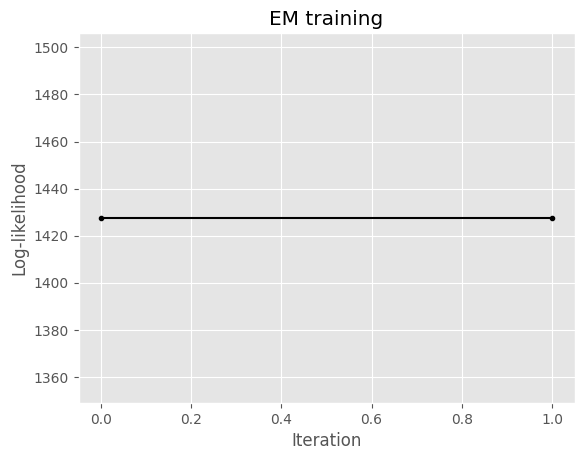

In [27]:
reg_coef = 1e-6
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X.to_numpy(),
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [28]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 6.26943727e+01,  6.24271837e+01,  3.14906423e+00,
         -1.54569084e-01,  3.30636230e-01,  3.43194057e-01,
          1.56546521e+01,  4.40271805e+00,  4.38027742e+00,
          1.24482447e-01,  4.17277381e-02,  7.59405941e-01,
          7.59900990e-01,  2.64851485e+00,  2.51485149e+00,
          2.63366337e+00,  2.54950495e+00,  3.14906423e-01,
         -2.52173705e-03,  1.84839305e-03,  2.40456293e-03,
         -2.08987997e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  9.85148515e-01,
          2.48175581e+00,  2.35885949e-01,  3.29182188e-02,
         -3.11734507e-02,  0.00000000e+00,  1.07838208e-01],
        [ 9.01278702e+01,  1.08022058e+01,  1.97855043e+01,
          1.82683693e+00,  2.51848308e-01,  5.64020852e-01,
          1.40696344e+01,  4.40957582e+00,  4.37330826e+00,
         -1.01326715e-01,  1.39156286e-01,  7.61691542e-01,
          7.61194030e-01,  2.76119403e+00,  2.62686567e+00,
          2.68656716e+00,  2.70149254e+

In [29]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(data.shape[0]):
#         ax.scatter(data[idx, :, 0], data[idx, :, 1], color="k", alpha=0.4)
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")

#     # xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
#     # pos = np.dstack((xg, yg))
#     # for jdx in range(K_components):
#     #     rv = rng.multivariate_normal(
#     #         mean=gmm.means_[jdx], cov=gmm.covariances_[jdx]
#     #     )
#     #     # ax.contour(xg, yg, rv.pdf(pos), levels=5, colors=cmap[jdx], alpha=0.8)
#     #     ax.scatter(gmm.means_[jdx, 0], gmm.means_[jdx, 1], c="k")#, color=cmap[jdx], marker="x", s=100)

#     fig.tight_layout()
#     plt.show()

### Metrics

In [30]:
# accu = accuracy_score(y_true=classes_gt, y_pred=clust_labels_pred)
# print(f"Accuracy: {accu}")

In [31]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.8560787100370664
Completeness: 1.0
Fowlkes-Mallows index: 1.0
Homogeneity: 1.0
Mutual Information: 1.09861228866811
Adjusted mutual information: 1.0
Normalized Mutual Information: 1.0
Rand index: 1.0
Adjusted rand index: 1.0
V-measure: 1.0


In [32]:
# pca = PCA(n_components=2)
# feat_mat_pca = pca.fit_transform(feat_mat)
# X_pca = pca.transform(X)
# feat_mat_pca.shape, X_pca.shape

In [33]:
# uncertainty = 1 - gamma_resp.max(axis=1)

In [34]:
def plot_cluster_res(U, X, Y, labels_gt, labels_pred, gamma_resp):

    # Transform data to first two principal components for plotting
    pca = PCA(n_components=2)
    U_pca = pca.fit_transform(U)
    X_pca = pca.transform(X)

    uncertainty = 1 - gamma_resp.max(axis=1)

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
        ax[0].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_gt, alpha=0.5, s=20)
        ax[0].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="x",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[0].set_title("True clusters")
        ax[1].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_pred, alpha=0.5, s=20)
        ax[1].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="x",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[1].set_title("Predicted clusters")
        ax[2].scatter(U_pca[:, 0], U_pca[:, 1], c=uncertainty, alpha=0.5, s=20)
        ax[2].set_title("Uncertainty")
        for axi in ax:
            axi.set_xlabel("PC 1")
            axi.set_ylabel("PC 2")
        for axi in ax[:2]:
            axi.legend(loc="best")
        for axi in ax[:2]:
            axi.legend(loc="best")
        fig.tight_layout()
        plt.show()

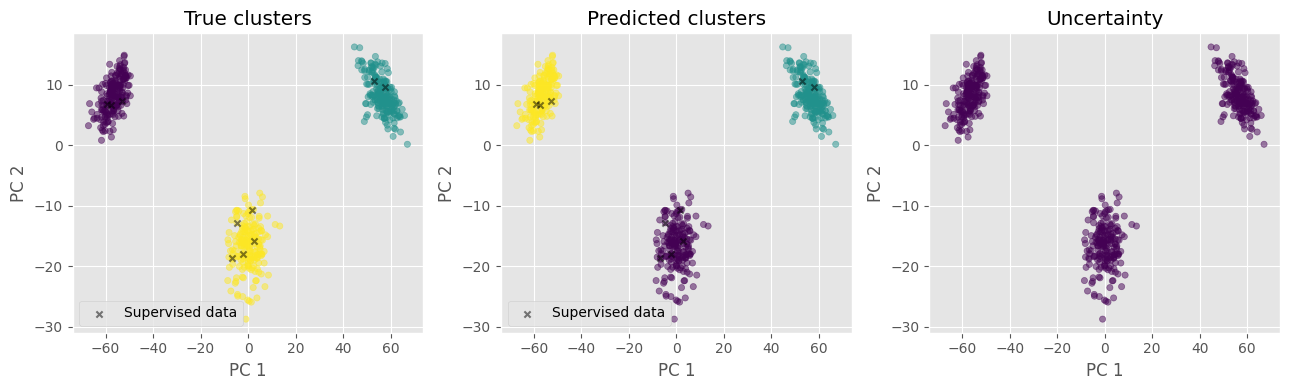

In [35]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=classes_gt,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
)

### New data

In [36]:
# new_data = np.random.normal(6, 1, 70)
# new_feat = np.array([np.mean(new_data), np.std(new_data)])[np.newaxis, :]
# new_feat

In [37]:
new_data = rng.multivariate_normal(
    mean=np.array([6, 1]), cov=covs, size=(seq_length * 2)
)
new_data.shape

(2000, 2)

In [38]:
# new_data_scaled = np.squeeze(scaler.transform(new_data))
# new_data_scaled.shape

In [39]:
new_windows = sliding_window(series=new_data, window_size=window_size, step=window_step)
new_windows.shape

(399, 10, 2)

In [40]:
new_feat_mat = pd.DataFrame(extract_features(new_windows))
new_feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,352.046601,9.502694,49.737845,1.978047,-0.261722,0.629360,104.833259,4.576306,4.242364,0.159998,...,0.0,0.0,0.0,1.0,4.251760,0.533298,-0.905536,-0.705453,0.0,0.729128
1,359.717527,7.981850,51.430119,1.978961,-0.261722,0.634733,108.294814,4.457998,3.941666,-1.151410,...,0.0,0.0,0.0,1.0,4.287770,0.585727,-0.483535,-0.310409,0.0,0.756028
2,359.562476,10.594420,50.143318,1.963167,-0.247033,0.772998,108.125874,3.967305,4.656275,0.534359,...,0.0,0.0,0.0,1.0,4.302074,0.414682,0.317852,-0.653875,0.0,0.723513
3,373.296037,10.785998,50.885636,1.970210,-0.263448,0.394349,114.151122,5.421117,3.682213,-0.526287,...,0.0,0.0,0.0,1.0,4.382248,0.432864,-0.013731,0.271370,0.0,0.718493
4,362.475228,10.788329,50.099635,1.967629,-0.247033,0.186993,109.412103,4.400979,4.571132,-0.231174,...,0.0,0.0,0.0,1.0,4.320090,0.576613,0.553924,0.742562,0.0,0.718446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,348.755681,12.289871,48.456396,1.937823,-0.261722,0.484978,102.930813,5.690672,3.709815,-0.691792,...,0.0,0.0,0.0,1.0,4.248797,0.333492,-0.746711,0.389435,0.0,0.705441
395,355.614787,14.640200,47.915991,1.961135,-0.261722,0.661996,106.818139,5.489582,4.444226,4.415827,...,0.0,0.0,0.0,1.0,4.302644,0.704447,-1.915737,-0.476135,0.0,0.678250
396,365.456437,9.587393,51.056055,1.975983,-0.247033,0.264458,110.808736,5.468791,4.244214,1.521926,...,0.0,0.0,0.0,1.0,4.330380,0.389071,1.448804,-0.188314,0.0,0.733949
397,363.952140,11.136882,50.205558,1.970025,-0.247033,0.761922,110.086136,3.471172,4.196379,-0.801453,...,0.0,0.0,0.0,1.0,4.330641,0.507248,-0.284669,-0.551076,0.0,0.717605


In [41]:
# new_feat_scaled = scaler.fit_transform(new_feat)
# new_feat_scaled = pd.DataFrame(new_feat_scaled)
# new_feat_scaled

In [42]:
# gmm.predict(new_feat_mat)

In [43]:
# np.round(gmm.predict_proba(new_feat_mat))

In [44]:
gamma_resp, labels_pred = predict(
    X=new_feat_mat.to_numpy(),
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    seed=seed,
)
gamma_resp, labels_pred

TypeError: e_step() got an unexpected keyword argument 'X'

In [ ]:
# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.clustering import TimeSeriesKMeans
# from tslearn.utils import to_time_series_dataset

# np.random.seed(0)
# time = np.linspace(0, 10, 50)
# series = [np.sin(time + shift) for shift in np.linspace(0, 3, 10)]
# dataset = to_time_series_dataset(series)

# scaler = TimeSeriesScalerMeanVariance()
# dataset_scaled = scaler.fit_transform(dataset)

# model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
# labels = model.fit_predict(dataset_scaled)

# print("Cluster Labels (Shape-Based):", labels)

## Lasa

In [45]:
resample_num = 2**10
print(f"Resampling to {resample_num} data points")
smoothing_factor = 0

Resampling to 1024 data points


In [46]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [47]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
classes_gt = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    # pos_resampled = pos
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        classes_gt = np.ones((pos_resampled.shape[0],), dtype=int) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        classes_gt = np.hstack(
            (classes_gt, np.ones(pos_resampled.shape[0], dtype=int) * idx)
        )
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(classes_gt.shape)
dataset = pd.DataFrame(
    {
        "t": X[:, 0],
        "pos_x": X[:, 1],
        "pos_y": X[:, 2],
        "y_cls": classes_gt,
    }
)
dataset

(3072, 3)
(3072,)


,t,pos_x,pos_y,y_cls
0,0.0,-31.414643,18.078238,0
1,1.0,-31.414425,18.078527,0
2,2.0,-31.413891,18.079220,0
3,3.0,-31.413022,18.080319,0
4,4.0,-31.411800,18.081830,0
...,...,...,...,...
3067,1019.0,0.001816,0.001816,2
3068,1020.0,0.000857,0.000857,2
3069,1021.0,0.000250,0.000250,2
3070,1022.0,-0.000002,-0.000002,2


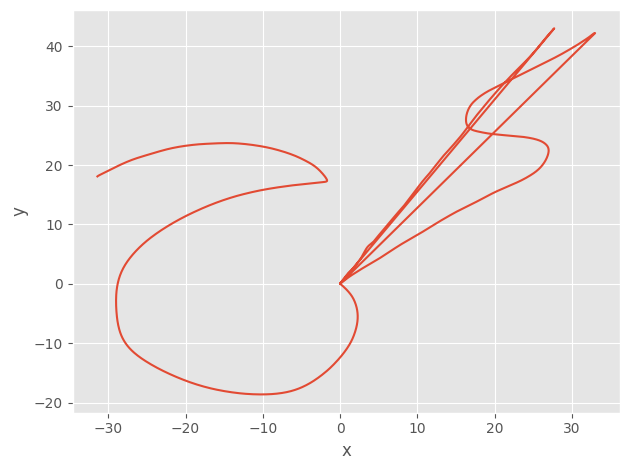

In [48]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(dataset.pos_x, dataset.pos_y)  # , c=blobs[1], alpha=0.5, s=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

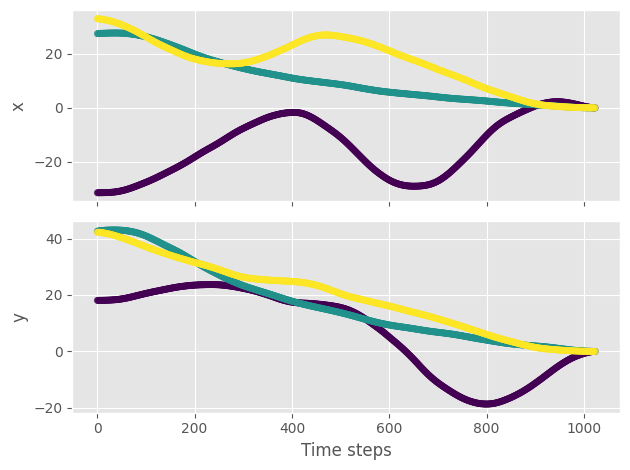

In [49]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1, sharex=True)
    ax[0].scatter(dataset.t, dataset.pos_x, c=dataset.y_cls, alpha=0.5, s=20)
    ax[1].scatter(dataset.t, dataset.pos_y, c=dataset.y_cls, alpha=0.5, s=20)
    ax[0].set_ylabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [50]:
dataset[["pos_x", "pos_y"]]

,pos_x,pos_y
0,-31.414643,18.078238
1,-31.414425,18.078527
2,-31.413891,18.079220
3,-31.413022,18.080319
4,-31.411800,18.081830
...,...,...
3067,0.001816,0.001816
3068,0.000857,0.000857
3069,0.000250,0.000250
3070,-0.000002,-0.000002


In [51]:
# scaler = TimeSeriesScalerMeanVariance()
# ds_scaled = np.squeeze(scaler.fit_transform(dataset[["pos_x", "pos_y"]]))
# ds_scaled.shape

In [52]:
windows = sliding_window(
    series=dataset[["pos_x", "pos_y"]], window_size=window_size, step=window_step
)
windows.shape

(613, 10, 2)

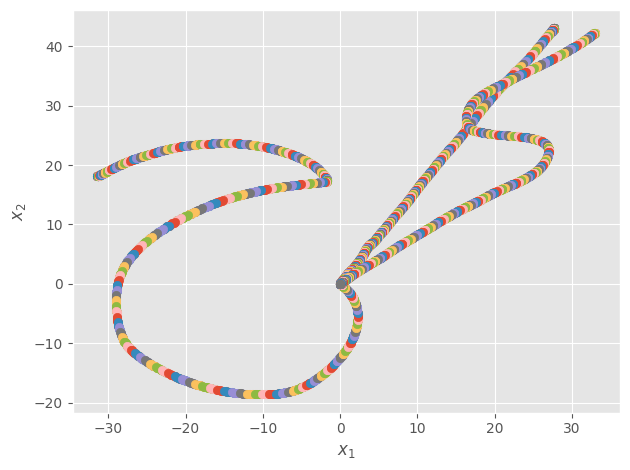

In [53]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

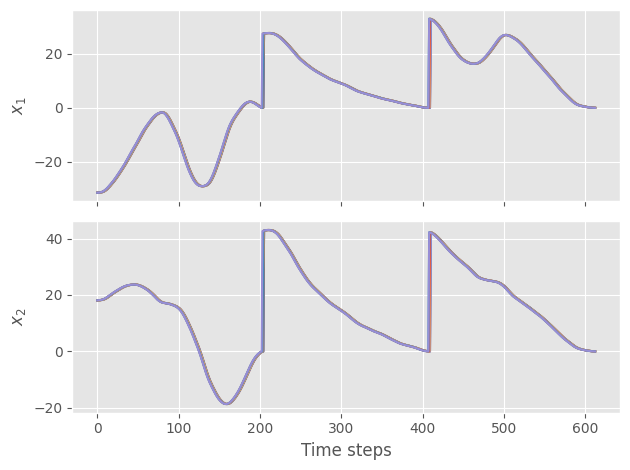

In [54]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[1]):
            ax[idx].plot(windows[:, jdx, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [55]:
feat_mat = extract_features(windows)
feat_mat.shape

(613, 33)

In [56]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,9865.556148,3270.477519,4.949394e+02,2.000000,0.062915,0.864123,-1.253636e+04,1.177736,1.154765,-0.436071,...,0.0,0.0,0.0,1.0,25.628142,0.242946,0.845209,0.781824,0.0,-3.714361
1,9857.342780,3275.774166,4.949550e+02,1.999999,0.062915,0.864123,-1.250983e+04,1.036605,1.032189,-1.273317,...,0.0,0.0,0.0,1.0,25.625297,0.242946,0.331213,0.282454,0.0,-3.722220
2,9844.628938,3283.517991,4.949662e+02,1.999999,0.062915,0.864123,-1.246938e+04,1.077593,1.068219,-1.013503,...,0.0,0.0,0.0,1.0,25.620448,0.242946,0.167125,0.105261,0.0,-3.733996
3,9827.260625,3293.153586,4.949550e+02,1.999998,0.062915,0.864123,-1.241542e+04,1.071804,1.056974,-1.043718,...,0.0,0.0,0.0,1.0,25.612901,0.242946,0.349061,0.235896,0.0,-3.749258
4,9801.228901,3305.906182,4.948904e+02,1.999997,0.062915,0.864123,-1.233687e+04,1.064599,1.055930,-1.084973,...,0.0,0.0,0.0,1.0,25.599937,0.242946,0.312708,0.227945,0.0,-3.770663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,0.073421,0.073421,6.643991e-14,-1.032588,-0.094032,-0.094032,5.983441e-04,1.045884,1.045884,-1.191771,...,0.0,0.0,0.0,1.0,0.085686,0.117783,0.107998,0.107998,0.0,0.182068
609,0.037145,0.037145,7.201878e-14,-1.033487,-0.544187,-0.544187,2.103639e-04,1.047095,1.047095,-1.184862,...,0.0,0.0,0.0,1.0,0.060947,0.117783,0.139445,0.139445,0.0,0.220884
610,0.016108,0.016108,8.124751e-14,-1.001447,0.160269,0.160269,5.753194e-05,1.065637,1.065637,-1.103618,...,0.0,0.0,0.0,1.0,0.040135,0.117783,0.120446,0.120446,0.0,0.283233
611,0.005192,0.005192,6.583189e-14,-1.121654,0.815904,0.815904,8.517755e-06,1.026773,1.026773,-1.345637,...,0.0,0.0,0.0,1.0,0.022785,0.117783,0.156285,0.156285,0.0,0.468211


In [57]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=dataset.y_cls, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)

In [58]:
K_components = len(datasets)
K_components

3

In [59]:
supervised_sample_size = 50
idx_superv = np.random.choice(
    np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
)
Y = np.zeros((len(idx_superv), K_components))
for idxi, idx_val in enumerate(idx_superv):
    Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# Y = classes_gt[idx_superv]
X = feat_mat.iloc[idx_superv, :]
X.shape, Y

((50, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],

In [60]:
# scaler = StandardScaler()
# feat_scaled = scaler.fit_transform(features)
# feat_scaled = pd.DataFrame(feat_scaled)
# # feat_scaled = features
# feat_scaled

In [61]:
# pca = PCA(n_components=2)
# feat_mat_pca = pca.fit_transform(feat_mat)
# X_pca = pca.transform(X)
# feat_mat_pca.shape, X_pca.shape

0/300 max iterations -- Log-likelihood: -24386.832378224433
10/300 max iterations -- Log-likelihood: -21667.440069354376
20/300 max iterations -- Log-likelihood: -20674.200258346686
30/300 max iterations -- Log-likelihood: -21225.680770796054
40/300 max iterations -- Log-likelihood: -21225.445129120548

--- Converged at iteration 41 ---



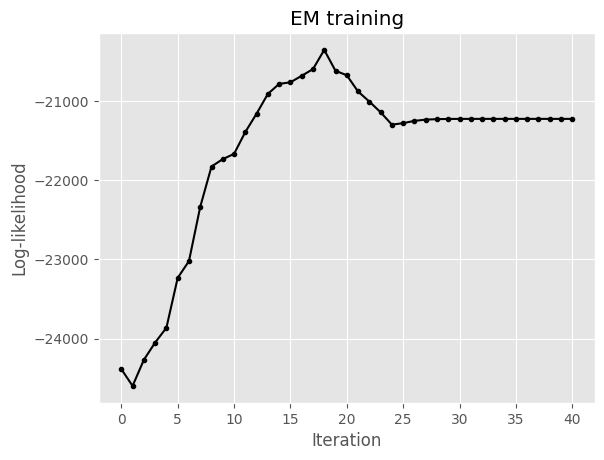

In [62]:
reg_coef = 1e-1
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X.to_numpy(),
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [63]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 1.51647515e+03,  1.97718779e+03,  8.18262053e+01,
          7.41592933e-01,  2.38847787e-01,  1.97018016e-01,
          1.22767538e+03,  8.58105258e-01,  8.05328275e-01,
         -2.21773689e-02, -2.57323623e-01,  4.60675762e-01,
          4.72759009e-01,  2.60944099e+00,  2.58116626e+00,
          2.90304612e+00,  2.95850149e+00,  8.18262053e+00,
          4.24022736e-01,  5.92638418e-01,  5.39844407e-02,
          8.34148031e-02,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  5.60247235e-01,
          8.24769099e+00,  1.39801042e-01,  1.48141489e-01,
          9.91836568e-02,  0.00000000e+00, -3.48003733e+00],
        [ 2.64353526e+03,  4.23746991e+03,  9.23206512e+01,
          1.75367411e+00,  3.61133205e-01,  3.47952945e-01,
          7.74776418e+03,  1.03408058e+00,  1.03153745e+00,
         -1.15163527e+00, -1.16323753e+00,  9.63468669e-01,
          9.70766889e-01,  4.92974687e+00,  4.92607995e+00,
          4.91482811e+00,  4.91873667e+

In [64]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [65]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [66]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: -0.20995221386458604
Completeness: 0.2812913744465922
Fowlkes-Mallows index: 0.5379075027161543
Homogeneity: 0.10173221903112628
Mutual Information: 0.1117631818746025
Adjusted mutual information: 0.14557474549088953
Normalized Mutual Information: 0.1494236710430318
Rand index: 0.41851922933393043
Adjusted rand index: 0.03510691150311896
V-measure: 0.1494236710430318


In [67]:
# uncertainty = 1 - gamma_resp.max(axis=1)

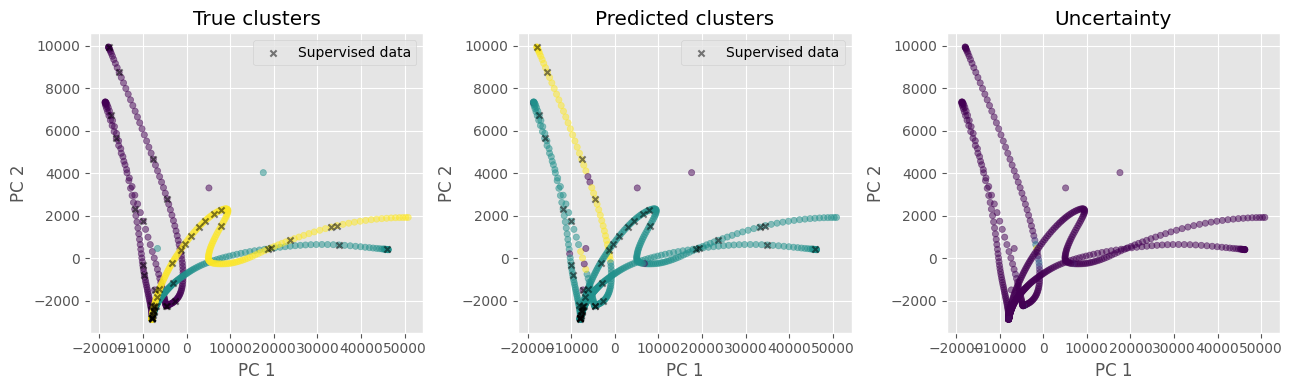

In [68]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
)

## Synthetic hierarchical (toy) data

In [69]:
# def plot_gaussian_hmm(
#     hmm, params, emissions, states, title="Emission Distributions", alpha=0.25
# ):
#     lim = 1.1 * abs(emissions).max()
#     XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
#     grid = jnp.column_stack((XX.ravel(), YY.ravel()))

#     plt.figure()
#     for k in range(hmm.num_states):
#         lls = hmm.emission_distribution(params, k).log_prob(grid)
#         plt.contour(
#             XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k])
#         )
#         plt.plot(
#             emissions[states == k, 0],
#             emissions[states == k, 1],
#             "o",
#             mfc=COLORS[k],
#             mec="none",
#             ms=3,
#             alpha=alpha,
#         )

#     plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
#     plt.xlabel("$y_1$")
#     plt.ylabel("$y_2$")
#     plt.title(title)
#     plt.gca().set_aspect(1.0)
#     plt.tight_layout()

In [70]:
def generate_two_level_hmm_sequence(
    seq_length,
    n_meta,
    n_sub,
    obs_dim,
    A_meta,
    A_sub,
    pi_meta,
    pi_sub,
    means,
    covariances,
    seed=None,
):
    """
    Generate sequence from a 2-level HMM.

    Parameters:
    - A_meta: (n_meta, n_meta) meta-state transition matrix
    - A_sub: (n_meta, n_sub, n_sub) sub-state transition (depends on meta)
    - pi_meta: (n_meta,) initial meta distribution
    - pi_sub: (n_meta, n_sub) initial sub distribution given meta
    - means: (n_meta, n_sub) observation means
    - covariances: (n_meta, n_sub, obs_dim, obs_dim) covariance matrices
    """
    rng = np.random.default_rng(seed)

    # Initialize arrays
    meta_states = np.zeros(seq_length, dtype=int)
    sub_states = np.zeros(seq_length, dtype=int)
    observations = np.zeros((seq_length, obs_dim))

    # Sample initial states
    meta_states[0] = rng.choice(n_meta, p=pi_meta)
    sub_states[0] = rng.choice(n_sub, p=pi_sub[meta_states[0]])

    # Generate first observation (multi-dimensional)
    observations[0] = rng.multivariate_normal(
        mean=means[meta_states[0], sub_states[0]],
        cov=covariances[meta_states[0], sub_states[0]],
    )

    # Generate rest of the sequence
    for t in range(1, seq_length):
        # Meta-state transition (depends only on previous meta)
        meta_states[t] = rng.choice(n_meta, p=A_meta[meta_states[t - 1]])

        # Check if meta-state changed
        if meta_states[t] != meta_states[t - 1]:
            # RESET: Sample sub-state from initial distribution
            sub_states[t] = rng.choice(n_sub, p=pi_sub[meta_states[t]])
        else:
            # Normal transition within same meta-state
            sub_states[t] = rng.choice(
                n_sub, p=A_sub[meta_states[t], sub_states[t - 1]]
            )

        # Multi-dimensional observation (depends on current meta and sub)
        observations[t] = rng.multivariate_normal(
            mean=means[meta_states[t], sub_states[t]],
            cov=covariances[meta_states[t], sub_states[t]],
            # size=(obs_dim),
        )

    return meta_states, sub_states, observations

In [71]:
n_meta = 3
n_sub = 4
obs_dim = 2

# Transition matrices
A_meta = np.array(
    [
        [0.8, 0.1, 0.1],  # from meta 0
        [0.1, 0.8, 0.1],  # from meta 1
        [0.1, 0.1, 0.8],  # from meta 2
    ]
)

# Sub-state transitions for each meta-state
A_sub = np.zeros((n_meta, n_sub, n_sub))
# Meta 0: tends to stay in same sub-state
A_sub[0] = np.array(
    [
        [0.7, 0.1, 0.1, 0.1],
        [0.1, 0.7, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.1, 0.1, 0.1, 0.7],
    ]
)
# Meta 1: tends to increase sub-state
A_sub[1] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)
# Meta 2: tends to decrease sub-state
# A_sub[2] = np.array(
#     [
#         [0.4, 0.0, 0.0, 0.6],
#         [0.6, 0.4, 0.0, 0.0],
#         [0.0, 0.6, 0.4, 0.0],
#         [0.0, 0.0, 0.6, 0.4],
#     ]
# )
# Meta 2: tends to increase sub-state
A_sub[2] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)

# Initial distributions
pi_meta = np.array([0.34, 0.33, 0.33])  # uniform-ish
# pi_sub = np.array(
#     [
#         [0.4, 0.3, 0.2, 0.1],  # given meta 0
#         [0.1, 0.2, 0.3, 0.4],  # given meta 1
#         [0.25, 0.25, 0.25, 0.25],  # given meta 2
#     ]
# )
pi_sub = np.array(
    [
        [0.6, 0.1, 0.2, 0.1],  # given meta 0
        [0.2, 0.6, 0.1, 0.1],  # given meta 1
        [0.0, 0.2, 0.6, 0.2],  # given meta 2
    ]
)


# Multi-dimensional observation parameters
means = np.zeros((n_meta, n_sub, obs_dim))
covariances = np.zeros((n_meta, n_sub, obs_dim, obs_dim))

# # Make means distinct for different meta-sub combinations
# for m in range(n_meta):
#     for s in range(n_sub):
#         means[m, s] = m * 10 + s * 2  # e.g., meta0: 0,2,4,6; meta1: 10,12,14,16; etc.

# Define different (meta, sub) pairs to have distinct 2D Gaussian distributions
for m in range(n_meta):
    for s in range(n_sub):
        # Different centers for each state
        means[m, s, :] = [
            m * 10 + s * 2,
            m * 5 + s * 1.5,
            # m * 15 + s * 2.5,
            # m * 20 + s * 1,
            # m * 0 + s * 0,
        ]

        # Different covariance structures
        if m == 0:  # Meta 0: isotropic
            covariances[m, s] = np.eye(obs_dim) * (s + 1)
        elif m == 1:  # Meta 1: correlated
            covariances[m, s] = np.array([[2.0, 0.8], [0.8, 1.0]]) * (s + 1)
        else:  # Meta 2: anti-correlated
            covariances[m, s] = np.array([[2.0, -0.5], [-0.5, 1.0]]) * (s + 1)

In [72]:
# Generate sequence
meta_states, sub_states, observations = generate_two_level_hmm_sequence(
    seq_length=seq_length,
    n_meta=n_meta,
    n_sub=n_sub,
    obs_dim=obs_dim,
    A_meta=A_meta,
    A_sub=A_sub,
    pi_meta=pi_meta,
    pi_sub=pi_sub,
    means=means,
    covariances=covariances,
    seed=seed,
)

print(f"Meta states:  {meta_states}")
print(f"Sub states:   {sub_states}")
print(f"Observations:\n{np.round(observations[:10, :], 2)}\n [...]")

Meta states:  [2 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 0 0 2 2 0 0 0 0 0 0 0 2 2 2
 2 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 2 2 2 2 2 2 2 1 2 1 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 1 0 0 0 0 0 0 0 0 0
 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 2 2 2 2 2 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 2
 2 2 2 1 1 2 2 2 2 2 2 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2
 2 2 1 1 1 2 2 2 2 2 2 2 2 2 2 2 1 2 2 1 1 2 2 2 2 2 2 1 0 0 1 0 0 0 0 1 1
 2 2 2 0 0 0 0 0 1 0 0 0 0 0 2 2 2 2 2 2 2 1 1 2 2 2 1 1 2 2 0 0 0 1 1 2 2
 2 2 2 2 2 2 2 0 2 2 2 2 2 1 1 1 0 2 2 2 2 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 1 1
 1 1 1 1 1 0 0 0 0 2 2 1 1 1 1 2 2 2 2 2 0 0 0 0 0 0 0 0 1 2 1 0 1 1 1 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 0 0 0 0 1 1 1 1 0 0 1
 1 1 2 2 2 

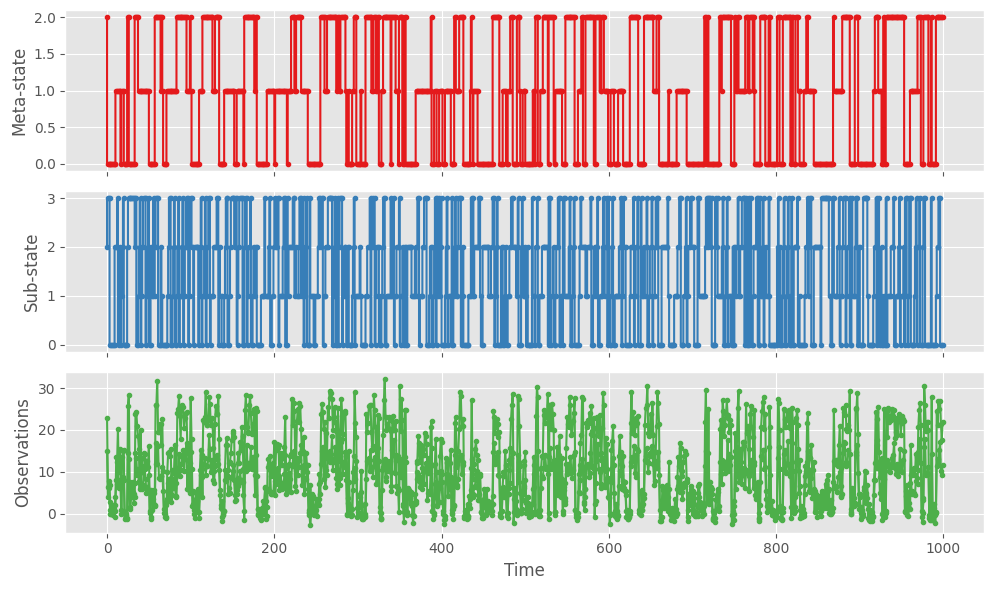

In [73]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["Set1"].colors
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6))
    axes[0].step(meta_states, ".-", c=cmap[0])
    axes[0].set_ylabel("Meta-state")
    axes[1].step(sub_states, ".-", c=cmap[1])
    axes[1].set_ylabel("Sub-state")
    axes[2].plot(observations, ".-", c=cmap[2])
    axes[2].set_ylabel("Observations")
    axes[2].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

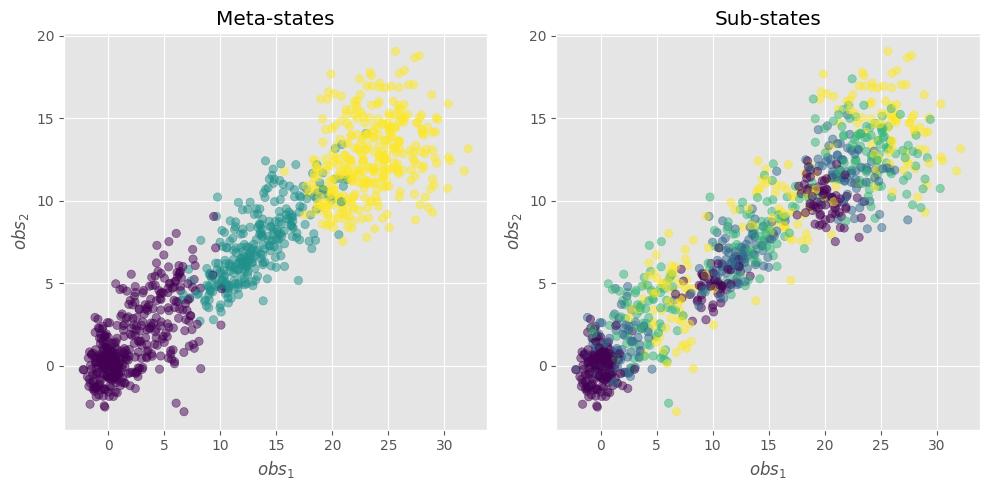

In [74]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=meta_states)
    ax[1].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=sub_states)
    ax[0].set_title("Meta-states")
    ax[1].set_title("Sub-states")
    for axi in ax:
        axi.set_xlabel(f"$obs_1$")
        axi.set_ylabel(f"$obs_2$")
    fig.tight_layout()
    plt.show()

In [75]:
windows = sliding_window(series=observations, window_size=window_size, step=window_step)
windows.shape

(199, 10, 2)

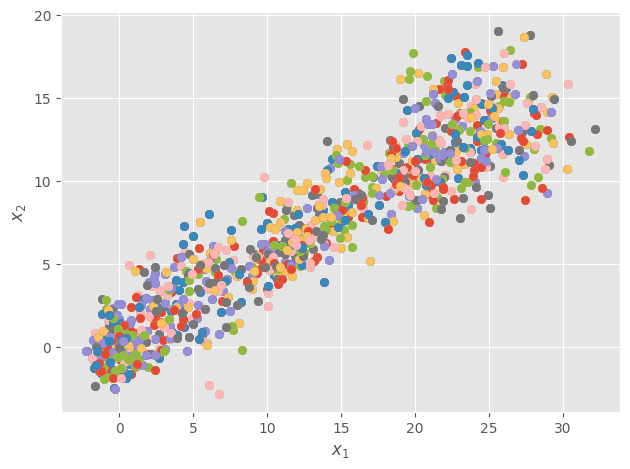

In [76]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

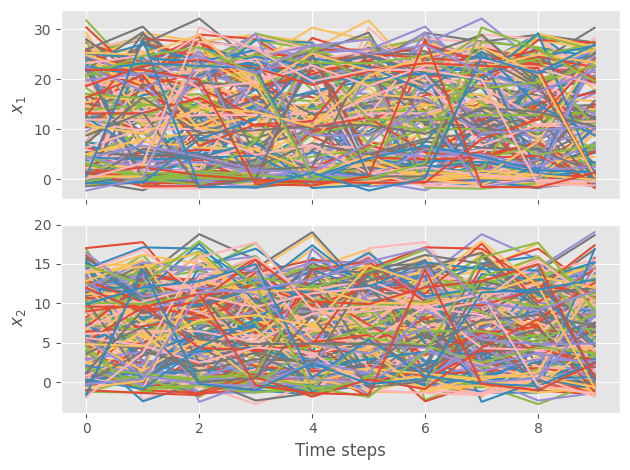

In [77]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            ax[idx].plot(windows[jdx, :, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [78]:
feat_mat = extract_features(windows)
feat_mat.shape

(199, 33)

In [79]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,674.144034,288.768962,22.945302,-0.601404,-0.025294,0.709353,42.842151,2.693654,2.743809,5.285951,...,0.0,0.0,0.0,1.0,6.938707,0.446287,2.166848,2.201973,0.0,1.482468
1,853.839443,300.424034,31.282725,-1.178621,0.822350,0.549349,43.408929,2.604282,2.211922,-0.467444,...,0.0,0.0,0.0,1.0,7.596919,0.530628,0.915748,0.612723,0.0,1.145392
2,1630.035048,565.258161,49.290146,0.132442,0.851382,0.019019,1076.773478,4.453304,4.761859,0.349244,...,0.0,0.0,0.0,1.0,10.476863,0.485508,-0.820156,-1.338630,0.0,0.549449
3,1019.156018,331.397361,33.759455,-0.247165,0.812934,-0.215303,384.065958,3.252008,3.355127,-2.422024,...,0.0,0.0,0.0,1.0,8.217522,0.650588,0.032248,-0.020620,0.0,1.118212
4,1826.075525,470.124963,47.942084,0.149716,0.668929,0.538402,884.372505,3.649669,3.957539,-0.289541,...,0.0,0.0,0.0,1.0,10.714944,0.650588,1.027928,1.086228,0.0,1.336376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,4176.364355,1509.626892,72.531958,0.163397,0.417850,0.821654,4514.451082,3.270352,3.178794,-1.216681,...,0.0,0.0,0.0,1.0,16.861185,0.318454,-0.761906,-0.714757,0.0,0.717187
195,3353.568580,976.437972,69.817192,-0.663680,0.735572,0.647613,1811.349533,3.024716,2.983793,-1.897274,...,0.0,0.0,0.0,1.0,14.713950,0.530628,-0.274425,-0.039729,0.0,0.944339
196,2149.030823,524.365684,53.009853,0.622730,0.889971,0.838043,1667.071771,3.892127,4.223440,-1.902764,...,0.0,0.0,0.0,1.0,11.561567,0.832909,0.566409,0.549852,0.0,1.459131
197,2572.108998,652.167538,57.483838,-1.035887,0.664865,0.979193,4.801465,3.745439,3.893816,-2.081256,...,0.0,0.0,0.0,1.0,12.697001,0.864997,0.518057,0.449871,0.0,1.398710


In [80]:
# pca = PCA(n_components=2)
# feat_mat_pca = pca.fit_transform(feat_mat)
# X_pca = pca.transform(X)
# feat_mat_pca.shape, X_pca.shape

### Meta-states clustering

In [81]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=meta_states, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)
y_cls_win

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 0,
       1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       2, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1])

In [89]:
supervised_sample_size = 50
idx_superv = np.random.choice(
    np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
)
Y = np.zeros((len(idx_superv), K_components))
for idxi, idx_val in enumerate(idx_superv):
    Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# Y = classes_gt[idx_superv]
X = feat_mat.iloc[idx_superv, :]
X.shape, Y

((50, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],

0/300 max iterations -- Log-likelihood: -9202.043277940627
10/300 max iterations -- Log-likelihood: -19014567.27191538
20/300 max iterations -- Log-likelihood: -18788538729.559364
30/300 max iterations -- Log-likelihood: -18788538729.650368
40/300 max iterations -- Log-likelihood: -18788538729.6511

--- Converged at iteration 44 ---



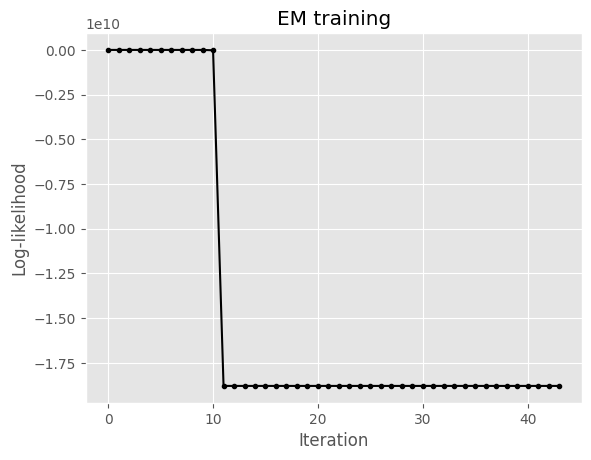

In [90]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X.to_numpy(),
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [91]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 3.62430458e+03,  1.08142326e+03,  8.16883646e+01,
          4.48970094e-01,  7.34126511e-01,  6.82715432e-01,
          3.56303374e+03,  3.81677692e+00,  3.99642060e+00,
          3.05156564e-01, -1.21056895e-02,  7.80598317e-01,
          8.24326930e-01,  4.28233353e+00,  3.88390581e+00,
          3.30494969e+00,  3.42817236e+

In [92]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 0,
        1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
        1, 1, 1, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
        2, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 0,
        1]),
 array([2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2,
        1, 1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2,
        1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 2, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 1,
        2, 2, 2, 2, 1, 2,

In [93]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.4875227608967209
Completeness: 0.47518915643912785
Fowlkes-Mallows index: 0.7561743966274793
Homogeneity: 0.39664062539021255
Mutual Information: 0.32358675231760037
Adjusted mutual information: 0.4283206882507154
Normalized Mutual Information: 0.4323764297043888
Rand index: 0.7607228059489366
Adjusted rand index: 0.5220175698101648
V-measure: 0.4323764297043889


In [94]:
# uncertainty = 1 - gamma_resp.max(axis=1)

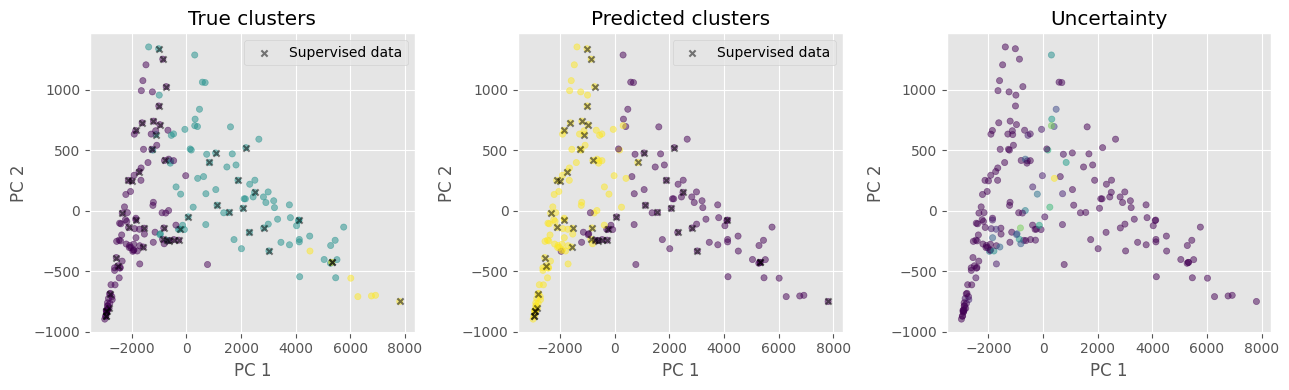

In [95]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
)

### Sub-states clustering

In [96]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=sub_states, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)
y_cls_win

array([1, 0, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 0, 1, 1, 1, 2, 2, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1])

In [103]:
supervised_sample_size = 50
idx_superv = np.random.choice(
    np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
)
Y = np.zeros((len(idx_superv), K_components))
for idxi, idx_val in enumerate(idx_superv):
    Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# Y = classes_gt[idx_superv]
X = feat_mat.iloc[idx_superv, :]
X.shape, Y

((50, 33),
 array([[1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],

0/300 max iterations -- Log-likelihood: -10925.348078430166
10/300 max iterations -- Log-likelihood: -9412.47617373996
20/300 max iterations -- Log-likelihood: -9641.772864124454
30/300 max iterations -- Log-likelihood: -11833.702497541806
40/300 max iterations -- Log-likelihood: -706382.3682925022
50/300 max iterations -- Log-likelihood: -21184485466.16278
60/300 max iterations -- Log-likelihood: -21184485466.8859
70/300 max iterations -- Log-likelihood: -21184485467.49367
80/300 max iterations -- Log-likelihood: -21184485468.29013
90/300 max iterations -- Log-likelihood: -21184485469.081665
100/300 max iterations -- Log-likelihood: -21184485469.545483
110/300 max iterations -- Log-likelihood: -21184485469.70414
120/300 max iterations -- Log-likelihood: -21184485469.742565
130/300 max iterations -- Log-likelihood: -21184485469.75061
140/300 max iterations -- Log-likelihood: -21184485469.752235
150/300 max iterations -- Log-likelihood: -21184485469.752556
160/300 max iterations -- Log-

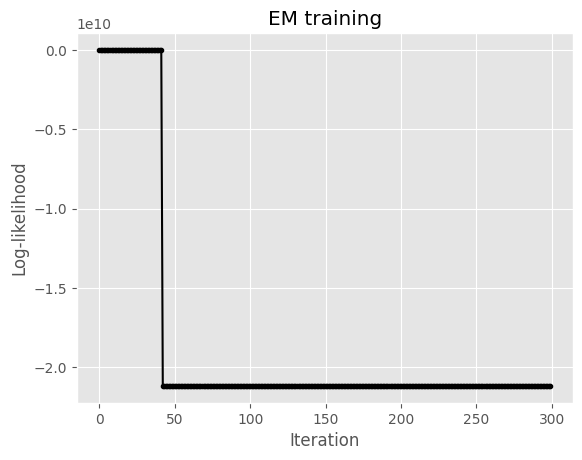

In [104]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X.to_numpy(),
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [105]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 2.37865854e+03,  7.19694508e+02,  6.31883905e+01,
         -3.08589638e-01,  8.34988431e-01,  6.64227736e-01,
          1.43108554e+03,  3.82840811e+00,  4.04658618e+00,
         -5.62752127e-01, -7.17040120e-01,  8.74622155e-01,
          9.14963020e-01,  4.47944497e+00,  4.29252201e+00,
          4.88039410e+00,  4.61940996e+00,  6.31883905e+00,
         -1.22037440e-01, -8.78503535e-02,  8.94321954e-03,
          9.31986461e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.20388757e+00,
          1.29407683e+01,  5.14641077e-01,  2.64007600e-01,
          2.54262135e-01,  0.00000000e+00,  1.05184576e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+

In [106]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.5620429214842922
Completeness: 0.049861361069939776
Fowlkes-Mallows index: 0.6101827629984289
Homogeneity: 0.040284075897425296
Mutual Information: 0.026653815836958694
Adjusted mutual information: 0.03602419753315703
Normalized Mutual Information: 0.044563960667638715
Rand index: 0.4985026140805035
Adjusted rand index: -0.09251831773561336
V-measure: 0.04456396066763871


In [107]:
# uncertainty = 1 - gamma_resp.max(axis=1)

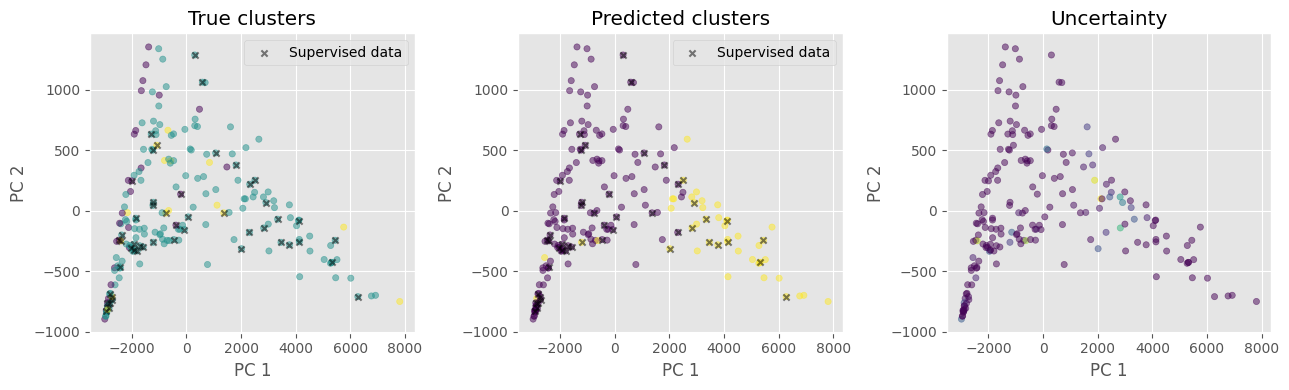

In [108]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
)